Feature engineering, encoding, model training, model comparison, and final model selection.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest ,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix




In [3]:
df = pd.read_csv('clean.csv')


In [4]:
df.drop(columns = 'Unnamed: 0', axis=1, inplace=True)

In [5]:
df.drop(columns = 'customerID', axis=1, inplace=True)

In [6]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
                                            
binary_cols = ['Partner','Dependents','PhoneService','Churn','gender']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [8]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7028,0,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7029,0,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7030,1,1,1,0,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


**Spliting Data**

In [10]:
x = df.drop('Churn' , axis = 1)
y = df['Churn']

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
x_train.shape

(5625, 19)

In [13]:
y_train.shape

(5625,)

**ENCODING**

In [15]:
cat_cols= [
    'gender','Partner','Dependents','Contract','OnlineBackup','OnlineSecurity',
    'PaymentMethod','InternetService','PhoneService','DeviceProtection',
    'TechSupport','StreamingTV','Churn','MultipleLines','StreamingMovies','PhoneService','PaperlessBilling'
]
for col in cat_cols:
    print(col, ":", df[col].unique())

gender : [0 1]
Partner : [1 0]
Dependents : [0 1]
Contract : ['Month-to-month' 'One year' 'Two year']
OnlineBackup : ['Yes' 'No' 'No internet service']
OnlineSecurity : ['No' 'Yes' 'No internet service']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
InternetService : ['DSL' 'Fiber optic' 'No']
PhoneService : [0 1]
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
Churn : [0 1]
MultipleLines : ['No phone service' 'No' 'Yes']
StreamingMovies : ['No' 'Yes' 'No internet service']
PhoneService : [0 1]
PaperlessBilling : ['Yes' 'No']


In [16]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

ordinal_cols = ['Contract']

ohe_cols = [
'OnlineBackup','OnlineSecurity','PaymentMethod','InternetService',
'DeviceProtection','TechSupport','StreamingTV','MultipleLines','StreamingMovies','PaperlessBilling'
]

encoder = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_cols)
], remainder='passthrough')

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ('encoder', encoder),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])
    
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7882
Decision Tree Accuracy: 0.7221
Random Forest Accuracy: 0.8010
XGBoost Accuracy: 0.7676
LightGBM Accuracy: 0.7854


In [19]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df

,Model,Accuracy
0,Logistic Regression,0.788202
1,Decision Tree,0.722104
2,Random Forest,0.800995
3,XGBoost,0.767591
4,LightGBM,0.785359


Multiple machine learning models were trained and evaluated. Random Forest achieved the best performance (~80% accuracy) and was selected as the final model.

In [21]:
pipe = Pipeline([
    ('encoder', encoder),
    ('scaler', MinMaxScaler()),
    ('model', RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
))
])

pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

acc = accuracy_score(y_test, y_pred)
print("Final Random Forest Accuracy:", acc)

Final Random Forest Accuracy: 0.8009950248756219


In [22]:
y_pred = pipe.predict(x_test)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.67      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



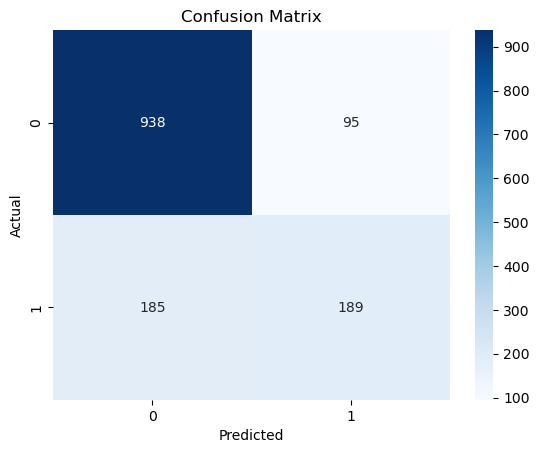

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The Random Forest model achieved an accuracy of approximately 80%.
The model correctly predicted 938 non-churn customers and 189 churn customers.
While the model performs well overall, the recall for churn customers indicates that some churn cases are still missed, suggesting further improvements such as class balancing or additional feature engineering could enhance performance.

In [56]:
import pickle

pickle.dump(pipe, open("Churnp_redictor_Model.pkl", "wb"))

In [27]:
print(x_train.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [28]:
x_train.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64